<a href="https://colab.research.google.com/github/Kachukwu-Goo/Internboot_Projects/blob/main/Project_o_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simple Sales Forecast with Moving Average**

A simple sales forecasting model using moving averages on the Favorita sales dataset, aggregated across all stores

In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving train.csv to train.csv
Saving transactions.csv to transactions.csv
Saving holidays_events.csv to holidays_events.csv
Saving oil.csv to oil.csv
Saving sample_submission.csv to sample_submission.csv
Saving stores.csv to stores.csv
Saving test.csv to test.csv
User uploaded file "train.csv" with length 121800373 bytes
User uploaded file "transactions.csv" with length 1552637 bytes
User uploaded file "holidays_events.csv" with length 22309 bytes
User uploaded file "oil.csv" with length 20580 bytes
User uploaded file "sample_submission.csv" with length 342153 bytes
User uploaded file "stores.csv" with length 1387 bytes
User uploaded file "test.csv" with length 1022269 bytes


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("whitegrid")

DATA_PATH = "train.csv"
STORE_ID = None   # None = aggregate across ALL stores

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
if STORE_ID is not None:
    df = df[df["store_nbr"] == STORE_ID]

In [4]:
# Collapse to one row per day, summed across all stores
daily_sales = (
    df.groupby("date", as_index=False)["sales"]
    .sum()
    .sort_values("date")
    .reset_index(drop=True)
).set_index("date")

In [5]:
# Resample, trim partial final period
weekly_sales = daily_sales["sales"].resample("W").sum().to_frame()
monthly_sales = daily_sales["sales"].resample("ME").sum().to_frame()

last_day = daily_sales.index.max()
if last_day.dayofweek != 6:
    weekly_sales = weekly_sales.iloc[:-1]
if last_day.day != last_day.days_in_month:
    monthly_sales = monthly_sales.iloc[:-1]

In [6]:
# Moving average forecast
WEEKLY_WINDOW, MONTHLY_WINDOW = 4, 3
weekly_sales["MA_forecast"] = weekly_sales["sales"].rolling(WEEKLY_WINDOW).mean().shift(1)
monthly_sales["MA_forecast"] = monthly_sales["sales"].rolling(MONTHLY_WINDOW).mean().shift(1)


In [16]:
#  Evaluating forecast accuracy
def evaluate_forecast(actual, forecast, label):
    valid = actual.notna() & forecast.notna()
    a, f = actual[valid], forecast[valid]
    mae = (a - f).abs().mean()
    rmse = np.sqrt(((a - f) ** 2).mean())
    mape = ((a - f).abs() / a.replace(0, np.nan)).mean() * 100
    print(f"--- {label} ---\nMAE: {mae:,.2f}\nRMSE: {rmse:,.2f}\nMAPE: {mape:,.2f}%\n")
    return mape

evaluate_forecast(weekly_sales["sales"], weekly_sales["MA_forecast"], "Weekly (all stores)")
evaluate_forecast(monthly_sales["sales"], monthly_sales["MA_forecast"], "Monthly (all stores)")

--- Weekly (all stores) ---
MAE: 373,163.29
RMSE: 536,602.23
MAPE: 8.39%

--- Monthly (all stores) ---
MAE: 2,258,315.12
RMSE: 2,953,957.12
MAPE: 12.06%



np.float64(12.055680963176721)

Weekly MAPE ≈ 8.4%
This means that the 4-week moving average missed actual weekly sales by about 8.4% on average, across the whole 4.5 year history. This is a reasonably tight fit for such a simple method. It means weekly sales don't swing wildly from one 4-week stretch to the next. There's a fairly stable underlying pattern the moving average can latch onto.

Monthly MAPE ≈ 12.1%
The 3-month moving average was off by about 12.1% at the monthly level, noticeably worse than the weekly version. you'd expect monthly totals, being bigger aggregates, to be smoother and easier to predict, but it makes sense once you think about why: monthly resampling only leaves you 56 data points to work with instead of 242, and a 3-month window reacts very slowly to the strong year-over-year growth trend and the sharp seasonal spikes (holidays) in this dataset. It has fewer opportunities to "catch up" before the next data point arrives.




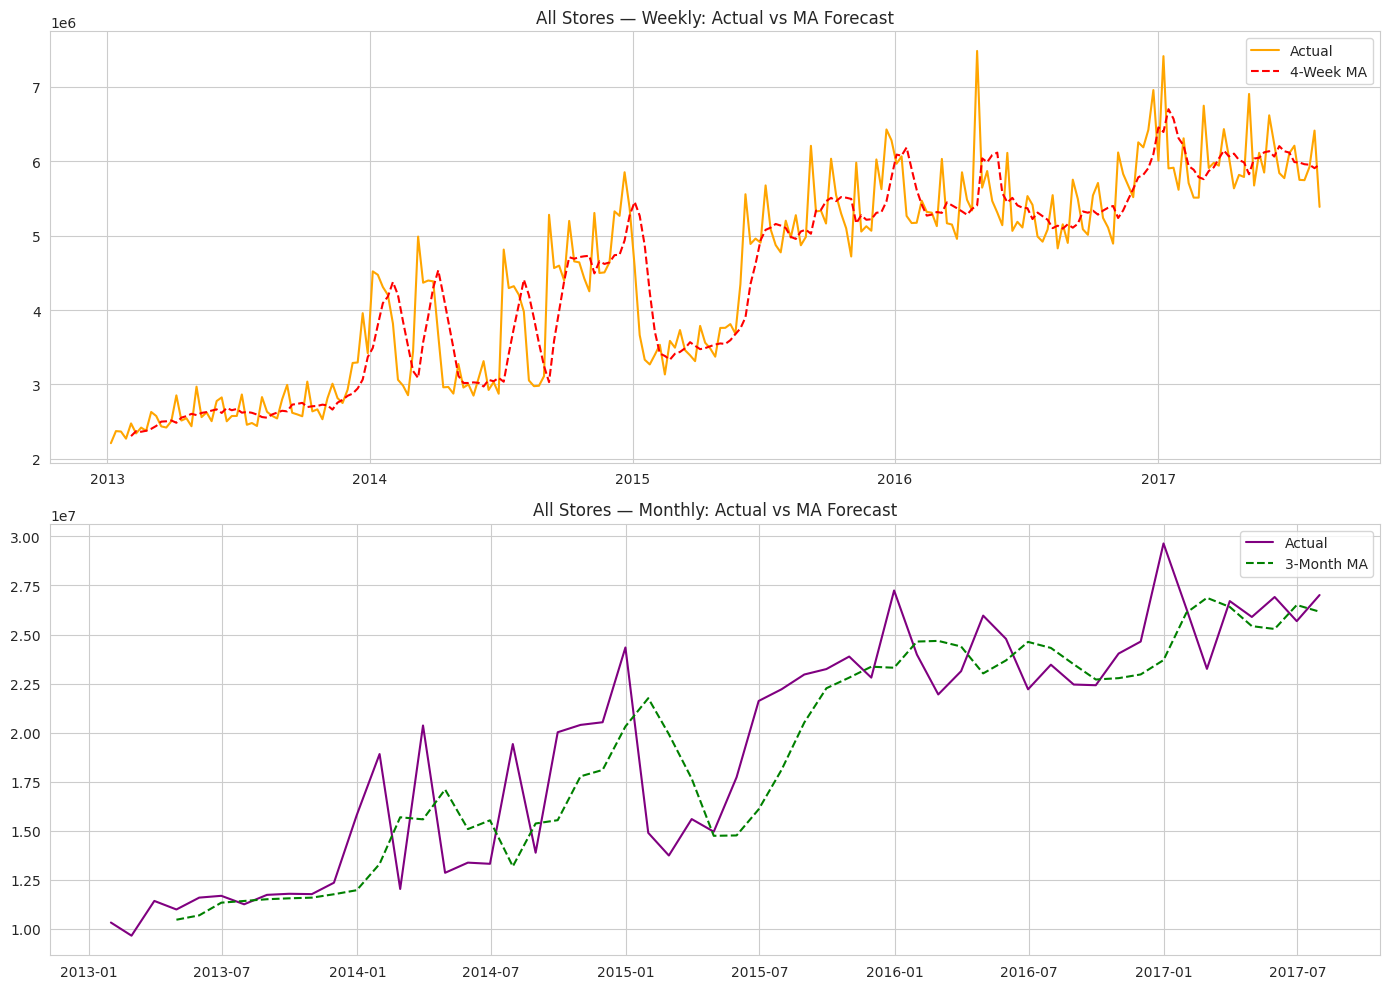

In [9]:
# Ploting actual vs. forecast sales
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes[0].plot(weekly_sales.index, weekly_sales["sales"], label="Actual", color="Orange")
axes[0].plot(weekly_sales.index, weekly_sales["MA_forecast"], label=f"{WEEKLY_WINDOW}-Week MA", color="Red", linestyle="--")
axes[0].set_title("All Stores — Weekly: Actual vs MA Forecast"); axes[0].legend()

axes[1].plot(monthly_sales.index, monthly_sales["sales"], label="Actual", color="Purple")
axes[1].plot(monthly_sales.index, monthly_sales["MA_forecast"], label=f"{MONTHLY_WINDOW}-Month MA", color="Green", linestyle="--")
axes[1].set_title("All Stores — Monthly: Actual vs MA Forecast"); axes[1].legend()
plt.tight_layout()
plt.show()

The chart showed the forecast line trailing just behind the real sales line especially around big spikes, like the holiday rushes each year. That's normal for a moving average: it can only look at what already happened, so it can't see a spike coming until it's already started.
the chart also shows us that
1. sales have a real yearly pattern. The gaps between the forecast and actual lines showed up around the same time each year, which means holidays genuinely drive sales up .

2. The business is growing. Both lines climbed steadily from 2013 to 2017, and the forecast kept pace with that overall growth just fine.

3. Monthly looked smoother but was actually less accurate. Fewer, bigger data points make the chart look calmer, but the model had less chance to correct itself between points, so it did a worse job (12.1% error vs 8.4% weekly).

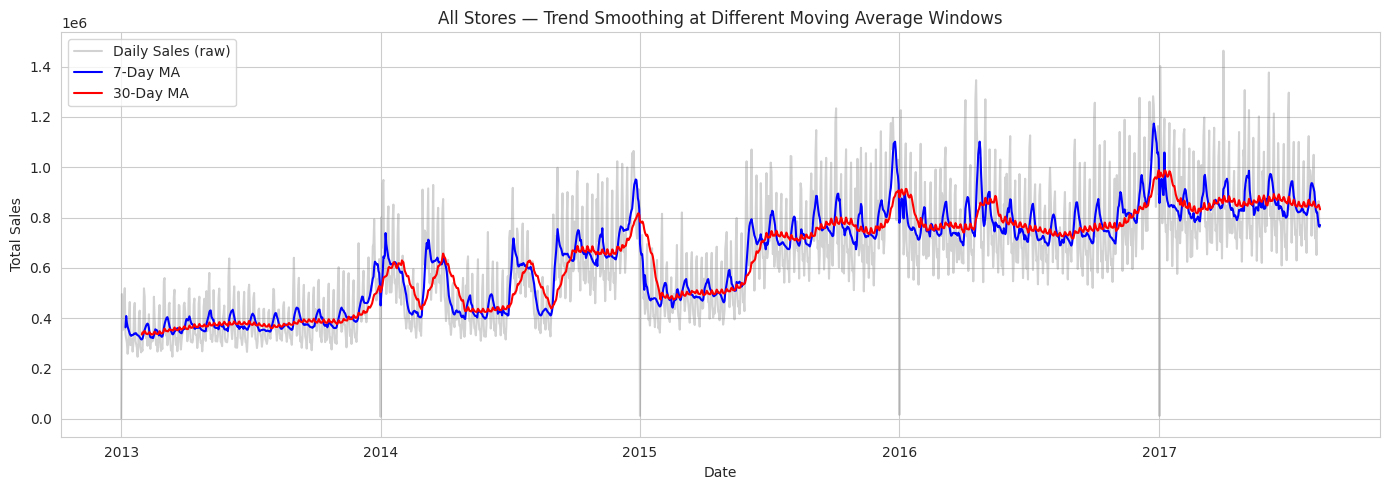

In [10]:
#Comparing window sizes on daily data  for aggregate
daily = daily_sales["sales"]

plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily, label="Daily Sales (raw)", alpha=0.35, color="gray")
plt.plot(daily.index, daily.rolling(7).mean(), label="7-Day MA", color="blue")
plt.plot(daily.index, daily.rolling(30).mean(), label="30-Day MA", color="red")
plt.title("All Stores — Trend Smoothing at Different Moving Average Windows")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()

This chart shows the 7 day average and 30 days average too. the 7 days average filtered out that daily noise but kept the weekly rhythm. It still showed clear spikes around holidays, meaning those spikes are a real, recurring feature of the data are not random blips.
The 30-day average filtered out almost everything except the big picture. It flattened out even the holiday spikes and just showed the underlying trend sales climbing steadily.
 This anaalysis has three layers stacked on top of each other; random daily noise, a repeating weekly/seasonal pattern, and a long-term growth trend. That's a useful diagnosis on its own, because it tells you a single flat "average" would hide all of that structure, and it's exactly why later steps are needed.

## **Overall,**
The moving average model did a solid job capturing the general upward trend in sales, with an average error of about 8.4% weekly and 12.1% monthly. The actual vs. forecast plot showed the forecast line tracking sales growth well but consistently lagging behind sharp seasonal spikes, such as holiday periods, since the model can only react to past data rather than anticipate sudden changes. The window size comparison reinforced this: a shorter 7-day window stayed closer to the real daily fluctuations but remained noisy, while a 30-day window was much smoother but slower to respond, flattening out even genuine spikes. Together, these visuals suggest that while moving averages are a good baseline for smoothing out noise and tracking long-term direction, a more adaptive method like exponential smoothing would likely improve forecast accuracy going forward."